In [ ]:
# check for version
# %pip install "numpy>=2.0.0"

In [ ]:
# run if unavailable
# !pip install --upgrade pip
# !pip install jax jaxlib jaxopt tinygp numpyro scikit-learn pandas matplotlib scipy

In [ ]:
# # run if required
# !rm -rf ~/extra_libs && mkdir -p ~/extra_libs
# !cd ~/extra_libs && wget -q http://archive.ubuntu.com/ubuntu/pool/main/libg/libglu/libglu1-mesa_9.0.2-1.1build1_amd64.deb
# !cd ~/extra_libs && ar x libglu1-mesa_9.0.2-1.1build1_amd64.deb
# !cd ~/extra_libs && tar -xf data.tar.*
# !cd ~/extra_libs && cp usr/lib/x86_64-linux-gnu/libGLU.so.1* /opt/conda/lib/
# !ls -l /opt/conda/lib/libGLU*

In [ ]:
import numpy as np
import pandas as pd
import time
import jax
import jax.numpy as jnp
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpyro
import numpyro.infer as infer
from GP_Training import GPModel
import numpyro.distributions as dist
from sklearn.mixture import GaussianMixture
import numpyro.diagnostics as diag

# --------------------------------------------------------------------------
class Bayesian_Inference:
    def __init__(self, gp_model, lower_bounds, upper_bounds, y_true, 
                 num_samples=2000, num_warmup=1000, num_chains=4):
        self.gp = gp_model
        self.sigma_obs = y_true * 0.01
        self.y_obs = self.generate_y_obs(y_true)
        self.lower_bounds = lower_bounds
        self.upper_bounds = upper_bounds
        self.num_samples = num_samples
        self.num_warmup = num_warmup
        self.num_chains = num_chains
        
        self.mean_ftr = None
        self.std_ftr = None
        self.gmm_jax = None
        self.X_ftr_scaled = None
        
        self.X_scaler = StandardScaler()
        
        init_shape = (len(self.lower_bounds),) if self.num_chains == 1 else (self.num_chains, len(self.lower_bounds))
        self.initial_x0 = {"x": np.random.normal(0.0, 0.5, size=init_shape)}
        # --------------------------------------------------------------------------
    def generate_y_obs(self, y):
        np.random.seed(7)
        y_obs = y + np.random.normal(0, self.sigma_obs)
        return y_obs


    def prior_fit(self, x):
        
        X_tr_cont = x[:, :7]
        # Scale( Fit & transform) continuous features: (X-X_hat)/var(X):
        X_scaled_cont = self.gp.X_scaler.transform(X_tr_cont)
        self.X_ftr_scaled = np.hstack((X_scaled_cont, x[:, 7:8]))

        self.mean_ftr = jnp.array(self.gp.X_scaler.mean_)
        self.std_ftr = jnp.array(self.gp.X_scaler.scale_)

        # cretae fitting object
        gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=7)
        # gmm_sklearn is fitted on scaled dataset
        gmm_model.fit(self.X_ftr_scaled)

        weights = jnp.array(gmm_model.weights_)
        means = jnp.array(gmm_model.means_)
        covs = jnp.array(gmm_model.covariances_)
        
        # fit gmm dist
        self.gmm_jax = dist.MixtureSameFamily(mixing_distribution=dist.Categorical(probs=weights),
            component_distribution=dist.MultivariateNormal(loc=means, covariance_matrix=covs))
        
    # --------------------------------------------------------------------------  
    # --------------------------------------------------------------------------
    def log_gmm_prior(self, x):
        # Scale x:
        x_cont_scaled = (x[:7] - self.mean_ftr) / self.std_ftr
        x_scaled = jnp.concatenate([x_cont_scaled, x[7:8]])
    
        return self.gmm_jax.log_prob(x_scaled)
    
    # --------------------------------------------------------------------------
    def log_likelihood(self, x):
        mu_x, std_x, _ = self.gp.predict(x)
        total_var = std_x**2 + (self.sigma_obs**2)
        log_l = -0.5 * ((self.y_obs - mu_x)**2 / total_var + jnp.log(2 * jnp.pi * total_var))
        return jnp.sum(log_l)
        


    def log_posterior(self, z):
        # Smoothly map z from (-inf, inf) to [lower_bounds, upper_bounds]
        sigmoid_z = jax.nn.sigmoid(z)
        x = self.lower_bounds + (self.upper_bounds - self.lower_bounds) * sigmoid_z
        
        # Log-determinant of Jacobian for sigmoid change of variables
        log_det_jacobian = jnp.sum(jnp.log(self.upper_bounds - self.lower_bounds)
                                   + jnp.log(sigmoid_z) + jnp.log(1 - sigmoid_z))
        
        # Flat prior in bounded space + likelihood + Jacobian correction
        return self.log_likelihood(x) + self.log_gmm_prior(x) + log_det_jacobian

    # --------------------------------------------------------------------------
        
    def sample(self, key):
        # Sample in unconstrained z space
        objective_fun = lambda p: -self.log_posterior(p["x"])
        
        kernel = infer.NUTS(potential_fn=objective_fun)
        mcmc = infer.MCMC(kernel, num_warmup=self.num_warmup, num_samples=self.num_samples, num_chains=self.num_chains)
        
        mcmc.run(key, init_params=self.initial_x0)
        mcmc.print_summary()
        
        # Map unconstrained z samples back to physical x parameters
        z_samples = mcmc.get_samples(group_by_chain=True)["x"]
        x_samples = self.lower_bounds + (self.upper_bounds - self.lower_bounds) * jax.nn.sigmoid(z_samples)
        return x_samples
        

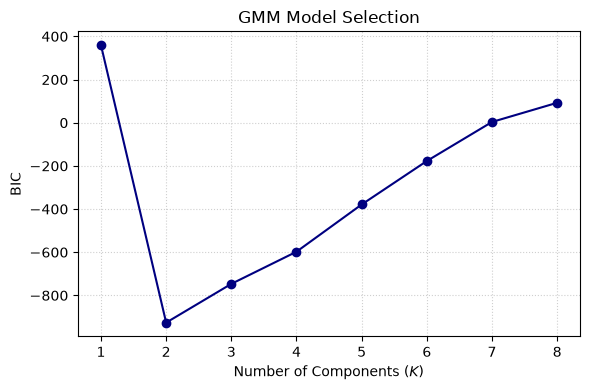

In [14]:
# run test: GMM model fit using BIc
if __name__ == "__main__":
    K_range = range(1, 9)  # Evaluate K from 1 to 8
    bics = []

    for k in K_range:
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
        gmm.fit(X_ftr)
        bics.append(gmm.bic(X_ftr))  # Auto-calculates k*ln(N) - 2*log_likelihood
    
    # Plotting the BIC/AIC Curve
    plt.figure(figsize=(6, 4))
    plt.plot(K_range, bics, label="BIC", marker="o", color="navy")
    
    plt.xlabel("Number of Components ($K$)")
    plt.ylabel("BIC")
    plt.title("GMM Model Selection")
    # plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("gmm_model_selection.png")  # Direct export for Overleaf
    plt.show()

In [8]:
# run test1: random sample parameter inference
if __name__ == "__main__":
    # generate y_true: FEM based
    df = pd.read_csv("simulation_200.csv")
    
    np.random.seed(42)
    row_idx = np.random.randint(0, len(df))
    y_true = df["P_eff"].iloc[row_idx]

    # feature extraction:
    feature_cols = ["fiber_vf", "f_r", "mu", "sigma", "db_t", 
                     "crc_no", "debond_fraction", "base_angle"]
    X_ftr = df[feature_cols].values
    
    mins = df[feature_cols].min().to_dict()
    maxs = df[feature_cols].max().to_dict()
    
    # Jax version input bounds
    lower_bounds = jnp.array([mins[col] for col in feature_cols])
    upper_bounds = jnp.array([maxs[col] for col in feature_cols])
    
    gp_model = GPModel()
    gp_model.GP_train("simulation_200.csv")
    # 
    BPI = Bayesian_Inference(gp_model, lower_bounds, upper_bounds, y_true, num_chains=4)
    BPI.prior_fit(X_ftr)
    
    key = jax.random.PRNGKey(7)
    posterior_samples = BPI.sample(key)



Exception ignored on calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f78f5fd3b00>:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.13/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/opt/conda/lib/python3.13/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/opt/conda/lib/python3.13/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/opt/conda/lib/python3.13/ctypes/__init__.py", line 361, in __init__
    self._handle = self._load_library(name, mode, handle, winmode)
  File "/opt/conda/lib/python3.13/ctypes/__init__.py", line 403, in _load_library
    return _dlopen(name, mode)
OSError: /opt/conda/lib/python3.13/site-packages/numpy.libs/libscipy_openblas64_-f48b354e


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      x[0]      1.25      0.95      1.06     -0.08      2.64   3889.31      1.00
      x[1]      0.35      1.20      0.28     -1.48      2.23   5588.37      1.00
      x[2]     -0.56      1.31     -0.60     -2.44      1.77   6739.92      1.00
      x[3]     -0.43      1.27     -0.39     -2.43      1.54   5544.37      1.00
      x[4]     -0.46      1.30     -0.38     -2.65      1.50   6370.95      1.00
      x[5]     -0.80      1.37     -0.72     -3.01      1.35   7739.46      1.00
      x[6]     -3.43      1.16     -3.20     -5.15     -1.75   3684.53      1.00
      x[7]     -0.12      1.35     -0.09     -2.32      1.88   6162.63      1.00

Number of divergences: 0


In [5]:
# full quantititaive chekc for test1
physical_x = np.reshape(posterior_samples, (4, -1, len(feature_cols)))

# 2. Compute grand means and standard deviations across all 4 chains
means = np.mean(physical_x, axis=(0, 1))
stds = np.std(physical_x, axis=(0, 1))

# 3. Compute 95% HPDI on flat samples
hpdi = diag.hpdi(physical_x.reshape(-1, len(feature_cols)), prob=0.95)
tol = 1e-3

print("=== Parameter Recovery & Credible Intervals (In-Domain) ===")
for i, col in enumerate(feature_cols):
    mean_val, std_val = means[i], stds[i]
    low, high = hpdi[0, i], hpdi[1, i]
    
    # Boundary snap for non-negative parameter edges
    if low < 1e-4:
        low = 0.0
        
    true_val = float(df[col].iloc[row_idx])
    is_inside = "✓" if (low - tol) <= true_val <= (high + tol) else "X"
    
    print(f"{col:15s} | True: {true_val:7.4f} | Mean ± SD: {mean_val:7.4f} ± {std_val:7.4f} | 95% HPDI: [{low:7.3f}, {high:7.3f}] {is_inside}")

# 4. Forward predictive evaluation at posterior grand mean E[X]
mu_pred, sig_pred, _ = gp_model.predict(jnp.array([means]))

p_eff_mean = float(mu_pred[0])
p_eff_std = float(sig_pred[0])
ci_lower = p_eff_mean - 1.96 * p_eff_std
ci_upper = p_eff_mean + 1.96 * p_eff_std
y_true_val = float(np.squeeze(y_true))
rel_error = (p_eff_mean - y_true_val) / y_true_val * 100

print("\n--- Output Model Check (In-Domain) ---")
print(f"Target   y_true: {y_true_val:.6f}")
print(f"Inferred P_eff: {p_eff_mean:.6f}  (95% CI: [{ci_lower:.6f}, {ci_upper:.6f}])")
print(f"Relative Error: {rel_error:.2f}%")

=== Parameter Recovery & Credible Intervals (In-Domain) ===
fiber_vf        | True:  0.2506 | Mean ± SD:  0.1839 ±  0.0471 | 95% HPDI: [  0.101,   0.268] ✓
f_r             | True:  0.4237 | Mean ± SD:  0.5669 ±  0.1115 | 95% HPDI: [  0.360,   0.779] ✓
mu              | True:  0.3324 | Mean ± SD:  0.5255 ±  0.1319 | 95% HPDI: [  0.304,   0.748] ✓
sigma           | True:  1.0508 | Mean ± SD:  1.7475 ±  0.3503 | 95% HPDI: [  1.132,   2.424] X
db_t            | True:  0.1053 | Mean ± SD:  0.0940 ±  0.0231 | 95% HPDI: [  0.050,   0.135] ✓
crc_no          | True:  7.0000 | Mean ± SD:  5.9369 ±  3.5663 | 95% HPDI: [  0.009,  12.474] ✓
debond_fraction | True:  0.2125 | Mean ± SD:  0.2675 ±  0.0606 | 95% HPDI: [  0.157,   0.388] ✓
base_angle      | True:  1.3401 | Mean ± SD:  1.4550 ±  0.7244 | 95% HPDI: [  0.133,   2.819] ✓

--- Output Model Check (In-Domain) ---
Target   y_true: 0.107988
Inferred P_eff: 0.111323  (95% CI: [0.106896, 0.115751])
Relative Error: 3.09%


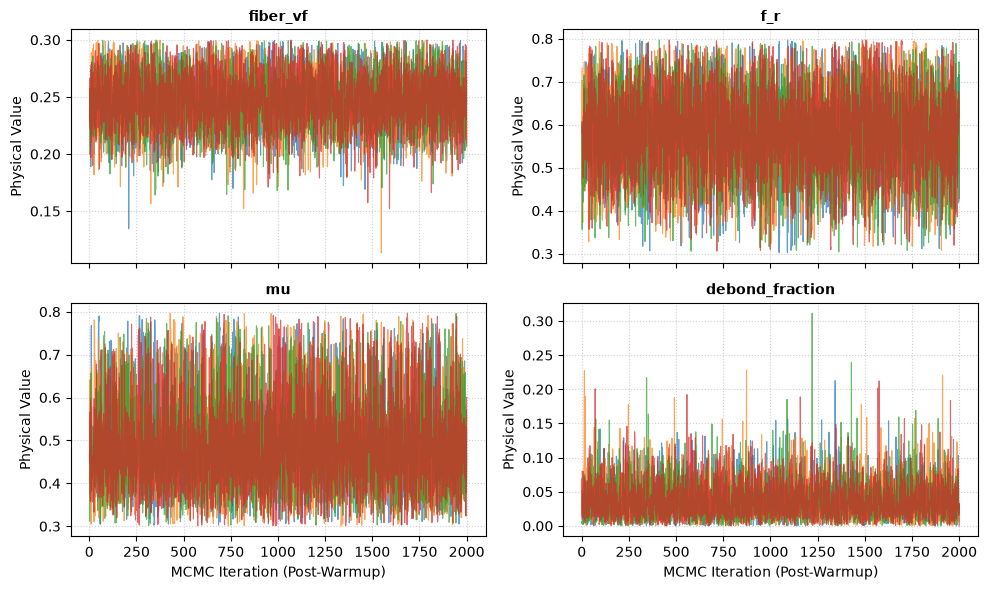

In [8]:
# run test 2: chains mixig plots
num_chains, num_samples, num_params = physical_x.shape
iterations = np.arange(1, num_samples + 1)

# Example: Plotting a 2x2 panel for 4 selected features
selected_indices = [0, 1, 2, 6]  # e.g., fiber_vf, f_r, mu, debond_fraction
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.flatten()

for i, param_idx in enumerate(selected_indices):
    ax = axes[i]
    for chain in range(num_chains):
        ax.plot(
            iterations,
            physical_x[chain, :, param_idx],
            alpha=0.7,
            linewidth=0.8,
            label=f"Chain {chain+1}",
        )

    ax.set_title(feature_cols[param_idx], fontsize=10, fontweight="bold")
    ax.set_ylabel("Physical Value")
    ax.grid(True, linestyle=":", alpha=0.6)

axes[2].set_xlabel("MCMC Iteration (Post-Warmup)")
axes[3].set_xlabel("MCMC Iteration (Post-Warmup)")
plt.tight_layout()
plt.savefig("mcmc_trace_plots.png")
plt.show()

In [9]:
# chekc quantitiative metrics for chains
table_data = []
for p_idx, name in enumerate(feature_cols):
    row = {"Parameter": name}
    for c in range(num_chains):
        c_mean = np.mean(physical_x[c, :, p_idx])
        c_std = np.std(physical_x[c, :, p_idx])
        row[f"Chain {c+1}"] = f"{c_mean:.4f} ± {c_std:.4f}"

    row["R-hat"] = f"{float(diag.gelman_rubin(physical_x[:, :, p_idx])):.4f}"
    row["ESS"] = (
        f"{float(diag.effective_sample_size(physical_x[:, :, p_idx])):.1f}"
    )
    table_data.append(row)

df_chains = pd.DataFrame(table_data)
print(df_chains.to_markdown(index=False))


| Parameter       | Chain 1         | Chain 2         | Chain 3         | Chain 4         |   R-hat |    ESS |
|:----------------|:----------------|:----------------|:----------------|:----------------|--------:|-------:|
| fiber_vf        | 0.2481 ± 0.0256 | 0.2487 ± 0.0264 | 0.2484 ± 0.0258 | 0.2489 ± 0.0259 |  0.9998 | 5884.9 |
| f_r             | 0.5795 ± 0.1053 | 0.5851 ± 0.1086 | 0.5789 ± 0.1069 | 0.5853 ± 0.1053 |  1.0003 | 7588.4 |
| mu              | 0.4986 ± 0.1141 | 0.4944 ± 0.1140 | 0.4940 ± 0.1104 | 0.4914 ± 0.1146 |  1.0001 | 6599.9 |
| sigma           | 1.6237 ± 0.3293 | 1.6399 ± 0.3293 | 1.6247 ± 0.3299 | 1.6299 ± 0.3447 |  1      | 7433.8 |
| db_t            | 0.0915 ± 0.0225 | 0.0915 ± 0.0223 | 0.0913 ± 0.0225 | 0.0913 ± 0.0228 |  0.9998 | 7902.5 |
| crc_no          | 5.2517 ± 3.2792 | 5.4355 ± 3.4641 | 5.2750 ± 3.3797 | 5.4430 ± 3.4172 |  1.0002 | 9524.9 |
| debond_fraction | 0.0354 ± 0.0282 | 0.0373 ± 0.0303 | 0.0369 ± 0.0304 | 0.0368 ± 0.0297 |  1.0001 | 5477.4 |
|

In [10]:
x_true = df[feature_cols].iloc[row_idx]

In [11]:
x_true

fiber_vf           0.221451
f_r                0.463900
mu                 0.459774
sigma              1.542788
db_t               0.128225
crc_no             3.000000
debond_fraction    0.000000
base_angle         1.608133
Name: 102, dtype: float64

In [18]:
# Test3 : out of distribution
from FEM_Solver import compute_P_eff
from MeshGenerator import Simulator
if __name__ == "__main__":
    
    # delta (10% range step), and u_OOD (+2 steps)
    mins = df[feature_cols].min().to_dict()
    maxs = df[feature_cols].max().to_dict()

    mins = np.array([mins[col] for col in feature_cols])
    maxs = np.array([maxs[col] for col in feature_cols])
    
    delta = 0.1 * (maxs - mins)

    X_ood = maxs + delta
    u_ood = maxs + 5 * delta

    # Specific treat crc_no as integer steps & lock base_angle at pi
    X_ood[5], u_ood[5] = 16, 20
    X_ood[7], u_ood[7] = 0, jnp.pi
    upper_bounds_ood = jnp.array(u_ood)
    
    X_ood_dict = {col: float(val) for col, val in zip(feature_cols, X_ood)}
    X_ood_dict["crc_no"] = int(X_ood_dict["crc_no"])
    X_ood_dict["mode"] = "mixed"
    X_test = X_ood_dict.pop("mode")
    # Initialize simulator with the relevant configurations
    sim = Simulator(**X_ood_dict)
    pts, tris, dims = sim.run_diffusion(X_test)
    
    
    # 3. FEM ---> y_obs
    # y_ood = gp_model.predict(jnp.array(X_ood)[None, :])[0]
    y_ood = compute_P_eff(pts, tris, dims)

    BPI_ood = Bayesian_Inference(gp_model, lower_bounds, upper_bounds_ood, y_ood, num_chains=4)
    BPI_ood.prior_fit(X_ftr)
    posterior_samples_ood = BPI_ood.sample(key)

Info    : [ 90%] Fragments                                                                                               

/tmp/ipykernel_245/1964141055.py:104: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = infer.MCMC(kernel, num_warmup=self.num_warmup, num_samples=self.num_samples, num_chains=self.num_chains)
sample: 100%|██████████| 3000/3000 [00:11<00:00, 271.01it/s, 15 steps of size 2.52e-01. acc. prob=0.89]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      x[0]      0.10      0.37      0.07     -0.48      0.72   5481.66      1.00
      x[1]     -2.99      1.17     -2.75     -4.73     -1.30   3529.05      1.00
      x[2]     -1.12      0.78     -0.94     -2.07     -0.07   1899.07      1.00
      x[3]     -1.16      0.90     -1.02     -2.49      0.19   3760.67      1.00
      x[4]     -0.64      0.48     -0.60     -1.38      0.17   6424.79      1.00
      x[5]     -1.88      1.25     -1.68     -3.81     -0.08   3613.28      1.00
      x[6]      0.11      0.34      0.07     -0.43      0.63   4241.06      1.00
      x[7]     -0.09      1.27     -0.06     -2.01      1.99   6396.09      1.00

Number of divergences: 1


In [21]:
# full quantititaive chekc for test3
physical_xood = np.reshape(posterior_samples_ood, (4, -1, len(feature_cols)))

# groun means/std
means = np.mean(physical_xood, axis=(0, 1))
stds = np.std(physical_xood, axis=(0, 1))

# 95% HPDI 
hpdi = diag.hpdi(physical_xood.reshape(-1, len(feature_cols)), prob=0.95)
tol = 1e-3

print("=== Parameter Recovery & Credible Intervals (OOD) ===")
for i, col in enumerate(feature_cols):
    mean_val, std_val = means[i], stds[i]
    low, high = hpdi[0, i], hpdi[1, i]
    
    # Boundary overflow prevention
    if low < 1e-4:
        low = 0.0
        
    true_val = float(X_ood[i])
    is_inside = "✓" if (low - tol) <= true_val <= (high + tol) else "X"
    
    print(f"{col:15s} | True: {true_val:7.4f} | Mean ± SD: {mean_val:7.4f} ± {std_val:7.4f} | 95% HPDI: [{low:7.3f}, {high:7.3f}] {is_inside}")

# Forward predictive evaluation at posterior grand mean E[X_OOD]
mu_pred, sig_pred, _ = gp_model.predict(jnp.array([means]))

# quantititaive chekc
p_eff_mean = float(mu_pred[0])
p_eff_std = float(sig_pred[0])
ci_lower = p_eff_mean - 1.96 * p_eff_std
ci_upper = p_eff_mean + 1.96 * p_eff_std
y_ood_val = float(np.squeeze(y_ood))
rel_error = (p_eff_mean - y_ood_val) / y_ood_val * 100

print("\n--- Output Model Check (OOD) ---")
print(f"Target   y_OOD: {y_ood_val:.6f}")
print(f"Inferred P_eff: {p_eff_mean:.6f}  (95% CI: [{ci_lower:.6f}, {ci_upper:.6f}])")
print(f"Relative Error: {rel_error:.2f}%")

=== Parameter Recovery & Credible Intervals (OOD) ===
fiber_vf        | True:  0.3050 | Mean ± SD:  0.3091 ±  0.0358 | 95% HPDI: [  0.238,   0.377] ✓
f_r             | True:  0.8094 | Mean ± SD:  0.3722 ±  0.0543 | 95% HPDI: [  0.302,   0.475] X
mu              | True:  0.8097 | Mean ± SD:  0.5691 ±  0.1032 | 95% HPDI: [  0.338,   0.748] X
sigma           | True:  2.5358 | Mean ± SD:  1.8111 ±  0.4014 | 95% HPDI: [  1.048,   2.536] ✓
db_t            | True:  0.1521 | Mean ± SD:  0.1206 ±  0.0203 | 95% HPDI: [  0.082,   0.161] ✓
crc_no          | True: 16.0000 | Mean ± SD:  4.5745 ±  3.3508 | 95% HPDI: [  0.005,  10.953] X
debond_fraction | True:  0.7942 | Mean ± SD:  0.8157 ±  0.1258 | 95% HPDI: [  0.591,   1.075] ✓
base_angle      | True:  0.0000 | Mean ± SD:  1.5231 ±  0.7155 | 95% HPDI: [  0.165,   2.856] X

--- Output Model Check (OOD) ---
Target   y_OOD: 0.310268
Inferred P_eff: 0.315208  (95% CI: [0.288100, 0.342315])
Relative Error: 1.59%
